In [33]:
import zipfile
import os
import cv2
import numpy as np

zip_path = "/content/archive (21).zip"
extract_destination = "brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_destination)

print("Dataset Extracted Successfully")

# Count the number of extracted files/images
extracted_image_count = 0
for dirpath, dirnames, filenames in os.walk(extract_destination):
    extracted_image_count += len(filenames)

print("Total images loaded:", extracted_image_count)

Dataset Extracted Successfully
Total images loaded: 506


In [34]:
images = []
labels = []

dataset_path = "brain_tumor_dataset"

for label_name in ["yes", "no"]:

    folder_path = os.path.join(dataset_path, label_name)

    for file in os.listdir(folder_path):

        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)

        if img is not None:

            images.append(img)

            if label_name == "yes":
                labels.append(1)
            else:
                labels.append(0)

print("Total images loaded:", len(images))
print("Total labels loaded:", len(labels))

Total images loaded: 253
Total labels loaded: 253


In [35]:
processed_images = []

for img in images:

    # Resize
    img = cv2.resize(img, (128, 128))

    # Convert to Grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Normalize
    img = img / 255.0

    # Flatten
    img = img.flatten()

    processed_images.append(img)

X = np.array(processed_images)
y = np.array(labels)

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (253, 16384)
Labels Shape: (253,)


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #keeps the same class ratio in both train and test
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (202, 16384)
Testing Data: (51, 16384)


In [37]:
# training using SVM (support vector machine)
from sklearn.svm import SVC

svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

print("SVM Model Trained Successfully")

SVM Model Trained Successfully


In [38]:
y_pred = svm_model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8823529411764706
Precision: 0.9032258064516129
Recall   : 0.9032258064516129
F1 Score : 0.9032258064516129

Confusion Matrix:
[[17  3]
 [ 3 28]]


In [40]:
#how this model works in unseen images
import cv2
import numpy as np

image_path = "/content/WhatsApp Image 2026-06-12 at 2.23.24 AM.jpeg"  # Replace with your unseen image

img = cv2.imread(image_path)

img = cv2.resize(img, (128, 128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = img / 255.0
img = img.flatten()

img = img.reshape(1, -1)

prediction = svm_model.predict(img)

if prediction[0] == 1:
    print("Tumor Detected")
else:
    print("No Tumor Detected")

Tumor Detected


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [42]:
y_pred_rf = rf_model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy : 0.8823529411764706
Precision: 0.8378378378378378
Recall   : 1.0
F1 Score : 0.9117647058823529

Confusion Matrix:
[[14  6]
 [ 0 31]]


In [44]:
import cv2
import numpy as np

# Path of unseen image
image_path = "/content/brain no tumor.jpg"   # Change this

# Load image
img = cv2.imread(image_path)

# Same preprocessing used during training
img = cv2.resize(img, (128, 128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = img / 255.0
img = img.flatten()

# Reshape for prediction
img = img.reshape(1, -1)

# Predict
prediction = rf_model.predict(img)

# Display result
if prediction[0] == 1:
    print("Tumor Detected")
else:
    print("No Tumor Detected")

No Tumor Detected


In [45]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [46]:
y_pred_lr = lr_model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.9019607843137255
Precision: 0.8823529411764706
Recall   : 0.967741935483871
F1 Score : 0.9230769230769231

Confusion Matrix:
[[16  4]
 [ 1 30]]


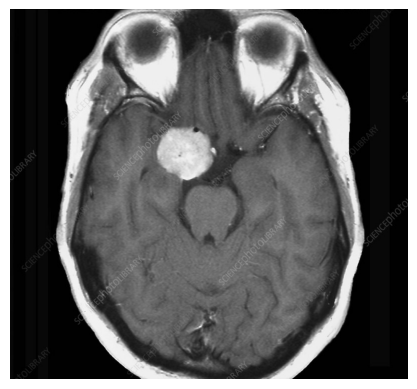

Tumor Detected


In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Path to unseen image
image_path = "/content/test_image3.jpg.jpeg"   # Change this

# Read image
img = cv2.imread(image_path)

# Display image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Preprocessing (same as training)
img = cv2.resize(img, (128, 128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = img / 255.0
img = img.flatten()

# Reshape for prediction
img = img.reshape(1, -1)

# Predict
prediction = lr_model.predict(img)

# Output
if prediction[0] == 1:
    print("Tumor Detected")
else:
    print("No Tumor Detected")

In [49]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["SVM", "Random Forest", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_lr)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_lr)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_lr)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_lr)
    ]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0                  SVM  0.882353   0.903226  0.903226  0.903226
1        Random Forest  0.882353   0.837838  1.000000  0.911765
2  Logistic Regression  0.901961   0.882353  0.967742  0.923077


In [50]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("\nBest Model:")
print(best_model)


Best Model:
Model        Logistic Regression
Accuracy                0.901961
Precision               0.882353
Recall                  0.967742
F1 Score                0.923077
Name: 2, dtype: object
